In [1]:
import os
import urllib.request
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()


def load_env(path: Path) -> dict:
    values = {}

    for line in path.read_text().splitlines():
        line = line.strip()

        if not line or line.startswith("#") or "=" not in line:
            continue

        key, _, value = line.partition("=")
        values[key.strip()] = value.strip().strip('"').strip("'")

    return values


env_path = REPO_ROOT / ".env"

if not env_path.exists():
    raise FileNotFoundError(
        f"Arquivo .env não encontrado em: {env_path}"
    )

env = {**load_env(env_path), **os.environ}

CH_HOST = env["CLICKHOUSE_HOST"]
CH_PORT = env["CLICKHOUSE_PORT"]
CH_USER = env["CLICKHOUSE_USER"]
CH_PASSWORD = env["CLICKHOUSE_PASSWORD"]
CH_DATABASE = env["CLICKHOUSE_DATABASE"]

JDBC_URL = (
    f"jdbc:clickhouse://{CH_HOST}:{CH_PORT}/"
    f"{CH_DATABASE}?ssl=true"
)

print(f"ClickHouse: {CH_HOST}:{CH_PORT}/{CH_DATABASE}")
print(f"Usuário: {CH_USER}")

ClickHouse: clickhouse-production-e204.up.railway.app:443/railway
Usuário: clickhouse


In [2]:
CLICKHOUSE_JDBC_VERSION = "0.8.6"

JDBC_DIR = REPO_ROOT / "jars"
JDBC_DIR.mkdir(exist_ok=True)

JDBC_JAR = (
    JDBC_DIR /
    f"clickhouse-jdbc-{CLICKHOUSE_JDBC_VERSION}-shaded-all.jar"
)

if not JDBC_JAR.exists():

    url = (
        "https://repo1.maven.org/maven2/com/clickhouse/"
        "clickhouse-jdbc/"
        f"{CLICKHOUSE_JDBC_VERSION}/"
        f"{JDBC_JAR.name}"
    )

    print("Baixando driver JDBC...")
    urllib.request.urlretrieve(url, JDBC_JAR)
    print("Download concluído!")

print("JDBC:", JDBC_JAR)
print("Existe:", JDBC_JAR.exists())

JDBC: C:\Users\Bruno\downloads\tcc_codigo\railway-ch\jars\clickhouse-jdbc-0.8.6-shaded-all.jar
Existe: True


In [3]:
import os
from pyspark.sql import SparkSession

# Configuração do Hadoop para Windows
os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["hadoop.home.dir"] = r"C:\hadoop"
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

# Garante que o driver JDBC seja carregado
# desde a inicialização do Spark
os.environ["PYSPARK_SUBMIT_ARGS"] = (
    f'--jars "{JDBC_JAR}" pyspark-shell'
)

spark = (
    SparkSession.builder
    .appName("ddos-exploratory-analysis")
    .master("local[*]")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark:", spark.version)
print("Spark funcionando!")

Spark: 4.2.0
Spark funcionando!


In [4]:
print("Testando driver JDBC...")

classloader = (
    spark._jvm.Thread
    .currentThread()
    .getContextClassLoader()
)

driver_class = classloader.loadClass(
    "com.clickhouse.jdbc.ClickHouseDriver"
)

print("Driver ClickHouse carregado com sucesso!")
print("Classe:", driver_class.getName())

Testando driver JDBC...
Driver ClickHouse carregado com sucesso!
Classe: com.clickhouse.jdbc.ClickHouseDriver


In [5]:
query = """
SELECT
    name AS tabela
FROM system.tables
WHERE database = currentDatabase()
ORDER BY name
"""

tabelas = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

tabelas.show(50, truncate=False)

+------------------+
|tabela            |
+------------------+
|data2_ldap        |
|data2_mssql       |
|data2_netbios     |
|data2_portmap     |
|data2_syn         |
|data2_udp         |
|data2_udplag      |
|data_drdos_dns    |
|data_drdos_ldap   |
|data_drdos_mssql  |
|data_drdos_netbios|
|data_drdos_ntp    |
|data_drdos_snmp   |
|data_drdos_ssdp   |
|data_drdos_udp    |
|data_syn          |
|data_tftp         |
|data_udplag       |
+------------------+



In [6]:
query = """
SELECT
    name AS tabela,
    toString(total_rows) AS total_rows
FROM system.tables
WHERE database = currentDatabase()
  AND name LIKE 'data%'
ORDER BY name
"""

tamanhos = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

tamanhos.show(50, truncate=False)

+------------------+----------+
|tabela            |total_rows|
+------------------+----------+
|data2_ldap        |2113234   |
|data2_mssql       |5775786   |
|data2_netbios     |3455899   |
|data2_portmap     |191694    |
|data2_syn         |4320541   |
|data2_udp         |3782206   |
|data2_udplag      |725165    |
|data_drdos_dns    |5074413   |
|data_drdos_ldap   |2181542   |
|data_drdos_mssql  |4524498   |
|data_drdos_netbios|4094986   |
|data_drdos_ntp    |1217007   |
|data_drdos_snmp   |5161377   |
|data_drdos_ssdp   |2611374   |
|data_drdos_udp    |3136802   |
|data_syn          |1582681   |
|data_tftp         |20107827  |
|data_udplag       |370605    |
+------------------+----------+



In [7]:
query = """
SELECT
    name AS coluna,
    type AS tipo
FROM system.columns
WHERE database = currentDatabase()
  AND table = 'data_drdos_dns'
ORDER BY position
"""

colunas = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

colunas.show(100, truncate=False)

+---------------------------+------+
|coluna                     |tipo  |
+---------------------------+------+
|unnamed_0                  |String|
|flow_id                    |String|
|source_ip                  |String|
|source_port                |String|
|destination_ip             |String|
|destination_port           |String|
|protocol                   |String|
|timestamp                  |String|
|flow_duration              |String|
|total_fwd_packets          |String|
|total_backward_packets     |String|
|total_length_of_fwd_packets|String|
|total_length_of_bwd_packets|String|
|fwd_packet_length_max      |String|
|fwd_packet_length_min      |String|
|fwd_packet_length_mean     |String|
|fwd_packet_length_std      |String|
|bwd_packet_length_max      |String|
|bwd_packet_length_min      |String|
|bwd_packet_length_mean     |String|
|bwd_packet_length_std      |String|
|flow_bytes_s               |String|
|flow_packets_s             |String|
|flow_iat_mean              |String|
|

In [8]:
query = """
SELECT
    label,
    toString(count(*)) AS quantidade
FROM data_drdos_dns
GROUP BY label
ORDER BY count(*) DESC
"""

classes = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

classes.show(100, truncate=False)

+---------+----------+
|label    |quantidade|
+---------+----------+
|DrDoS_DNS|5071011   |
|BENIGN   |3402      |
+---------+----------+



In [9]:
query = """
SELECT
    toString(countIf(label = '')) AS labels_vazios,
    toString(countIf(protocol = '')) AS protocol_vazios,
    toString(countIf(flow_duration = '')) AS flow_duration_vazios
FROM data_drdos_dns
"""

nulos_teste = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

nulos_teste.show(truncate=False)

+-------------+---------------+--------------------+
|labels_vazios|protocol_vazios|flow_duration_vazios|
+-------------+---------------+--------------------+
|0            |0              |0                   |
+-------------+---------------+--------------------+



In [10]:
# Obtém os nomes das 88 colunas
nomes_colunas = [row["coluna"] for row in colunas.collect()]

# Cria uma expressão countIf para cada coluna
expressoes = []

for nome in nomes_colunas:
    expressoes.append(
        f"toString(countIf(`{nome}` = '')) AS `{nome}`"
    )

query = f"""
SELECT
    {", ".join(expressoes)}
FROM data_drdos_dns
"""

nulos = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

nulos.show(truncate=False)

+---------+-------+---------+-----------+--------------+----------------+--------+---------+-------------+-----------------+----------------------+---------------------------+---------------------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+------------+--------------+-------------+------------+------------+------------+-------------+------------+-----------+-----------+-----------+-------------+------------+-----------+-----------+-----------+-------------+-------------+-------------+-------------+-----------------+-----------------+-------------+-------------+-----------------+-----------------+------------------+-----------------+----------------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+-------------------+--------------------+--------------------+

In [11]:
query = """
SELECT
    toString(countIf(lower(flow_bytes_s) IN ('inf', '+inf', '-inf', 'infinity', '+infinity', '-infinity'))) AS flow_bytes_s_inf,
    toString(countIf(lower(flow_packets_s) IN ('inf', '+inf', '-inf', 'infinity', '+infinity', '-infinity'))) AS flow_packets_s_inf,
    toString(countIf(lower(fwd_packets_s) IN ('inf', '+inf', '-inf', 'infinity', '+infinity', '-infinity'))) AS fwd_packets_s_inf,
    toString(countIf(lower(bwd_packets_s) IN ('inf', '+inf', '-inf', 'infinity', '+infinity', '-infinity'))) AS bwd_packets_s_inf
FROM data_drdos_dns
"""

infinitos = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

infinitos.show(truncate=False)

+----------------+------------------+-----------------+-----------------+
|flow_bytes_s_inf|flow_packets_s_inf|fwd_packets_s_inf|bwd_packets_s_inf|
+----------------+------------------+-----------------+-----------------+
|162363          |162394            |0                |0                |
+----------------+------------------+-----------------+-----------------+



In [12]:
# Colunas que serão analisadas como numéricas
colunas_numericas = [
    "flow_duration",
    "total_fwd_packets",
    "total_backward_packets",
    "total_length_of_fwd_packets",
    "total_length_of_bwd_packets",
    "fwd_packet_length_max",
    "fwd_packet_length_min",
    "fwd_packet_length_mean",
    "fwd_packet_length_std",
    "bwd_packet_length_max",
    "bwd_packet_length_min",
    "bwd_packet_length_mean",
    "bwd_packet_length_std",
    "flow_bytes_s",
    "flow_packets_s",
    "flow_iat_mean",
    "flow_iat_std",
    "flow_iat_max",
    "flow_iat_min",
    "fwd_iat_total",
    "fwd_iat_mean",
    "fwd_iat_std",
    "fwd_iat_max",
    "fwd_iat_min",
    "bwd_iat_total",
    "bwd_iat_mean",
    "bwd_iat_std",
    "bwd_iat_max",
    "bwd_iat_min",
    "fwd_header_length",
    "bwd_header_length",
    "fwd_packets_s",
    "bwd_packets_s",
    "min_packet_length",
    "max_packet_length",
    "packet_length_mean",
    "packet_length_std",
    "packet_length_variance",
    "fin_flag_count",
    "syn_flag_count",
    "rst_flag_count",
    "psh_flag_count",
    "ack_flag_count",
    "urg_flag_count",
    "cwe_flag_count",
    "ece_flag_count",
    "down_up_ratio",
    "average_packet_size",
    "avg_fwd_segment_size",
    "avg_bwd_segment_size",
    "fwd_header_length_1",
    "fwd_avg_bytes_bulk",
    "fwd_avg_packets_bulk",
    "fwd_avg_bulk_rate",
    "bwd_avg_bytes_bulk",
    "bwd_avg_packets_bulk",
    "bwd_avg_bulk_rate",
    "subflow_fwd_packets",
    "subflow_fwd_bytes",
    "subflow_bwd_packets",
    "subflow_bwd_bytes",
    "init_win_bytes_forward",
    "init_win_bytes_backward",
    "act_data_pkt_fwd",
    "min_seg_size_forward",
    "active_mean",
    "active_std",
    "active_max",
    "active_min",
    "idle_mean",
    "idle_std",
    "idle_max",
    "idle_min"
]

expressoes_inf = []

for nome in colunas_numericas:
    expressoes_inf.append(
        f"""
        toString(countIf(
            lower(`{nome}`) IN (
                'inf', '+inf', '-inf',
                'infinity', '+infinity', '-infinity'
            )
        )) AS `{nome}`
        """
    )

query = f"""
SELECT
    {",".join(expressoes_inf)}
FROM data_drdos_dns
"""

infinitos_todas = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

# Transforma o resultado em uma lista apenas com as colunas que possuem infinitos
resultado_inf = infinitos_todas.collect()[0].asDict()

for coluna, quantidade in resultado_inf.items():
    if quantidade != "0":
        print(f"{coluna}: {quantidade}")

flow_bytes_s: 162363
flow_packets_s: 162394


In [13]:
query = """
SELECT
    toString(count(*) - uniqExact(
        tuple(
            unnamed_0,
            flow_id,
            source_ip,
            source_port,
            destination_ip,
            destination_port,
            protocol,
            timestamp,
            flow_duration,
            total_fwd_packets,
            total_backward_packets,
            total_length_of_fwd_packets,
            total_length_of_bwd_packets,
            fwd_packet_length_max,
            fwd_packet_length_min,
            fwd_packet_length_mean,
            fwd_packet_length_std,
            bwd_packet_length_max,
            bwd_packet_length_min,
            bwd_packet_length_mean,
            bwd_packet_length_std,
            flow_bytes_s,
            flow_packets_s,
            flow_iat_mean,
            flow_iat_std,
            flow_iat_max,
            flow_iat_min,
            fwd_iat_total,
            fwd_iat_mean,
            fwd_iat_std,
            fwd_iat_max,
            fwd_iat_min,
            bwd_iat_total,
            bwd_iat_mean,
            bwd_iat_std,
            bwd_iat_max,
            bwd_iat_min,
            fwd_psh_flags,
            bwd_psh_flags,
            fwd_urg_flags,
            bwd_urg_flags,
            fwd_header_length,
            bwd_header_length,
            fwd_packets_s,
            bwd_packets_s,
            min_packet_length,
            max_packet_length,
            packet_length_mean,
            packet_length_std,
            packet_length_variance,
            fin_flag_count,
            syn_flag_count,
            rst_flag_count,
            psh_flag_count,
            ack_flag_count,
            urg_flag_count,
            cwe_flag_count,
            ece_flag_count,
            down_up_ratio,
            average_packet_size,
            avg_fwd_segment_size,
            avg_bwd_segment_size,
            fwd_header_length_1,
            fwd_avg_bytes_bulk,
            fwd_avg_packets_bulk,
            fwd_avg_bulk_rate,
            bwd_avg_bytes_bulk,
            bwd_avg_packets_bulk,
            bwd_avg_bulk_rate,
            subflow_fwd_packets,
            subflow_fwd_bytes,
            subflow_bwd_packets,
            subflow_bwd_bytes,
            init_win_bytes_forward,
            init_win_bytes_backward,
            act_data_pkt_fwd,
            min_seg_size_forward,
            active_mean,
            active_std,
            active_max,
            active_min,
            idle_mean,
            idle_std,
            idle_max,
            idle_min,
            simillarhttp,
            inbound,
            label
        )
    )) AS registros_duplicados
FROM data_drdos_dns
"""

duplicatas = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

duplicatas.show(truncate=False)

+--------------------+
|registros_duplicados|
+--------------------+
|0                   |
+--------------------+



In [14]:
query = """
SELECT
    'flow_duration' AS coluna,
    toString(countIf(isFinite(toFloat64OrNull(flow_duration)))) AS valores_validos,
    toString(minIf(toFloat64OrNull(flow_duration), isFinite(toFloat64OrNull(flow_duration)))) AS minimo,
    toString(maxIf(toFloat64OrNull(flow_duration), isFinite(toFloat64OrNull(flow_duration)))) AS maximo,
    toString(avgIf(toFloat64OrNull(flow_duration), isFinite(toFloat64OrNull(flow_duration)))) AS media
FROM data_drdos_dns

UNION ALL

SELECT
    'total_fwd_packets',
    toString(countIf(isFinite(toFloat64OrNull(total_fwd_packets)))),
    toString(minIf(toFloat64OrNull(total_fwd_packets), isFinite(toFloat64OrNull(total_fwd_packets)))),
    toString(maxIf(toFloat64OrNull(total_fwd_packets), isFinite(toFloat64OrNull(total_fwd_packets)))),
    toString(avgIf(toFloat64OrNull(total_fwd_packets), isFinite(toFloat64OrNull(total_fwd_packets))))
FROM data_drdos_dns

UNION ALL

SELECT
    'total_backward_packets',
    toString(countIf(isFinite(toFloat64OrNull(total_backward_packets)))),
    toString(minIf(toFloat64OrNull(total_backward_packets), isFinite(toFloat64OrNull(total_backward_packets)))),
    toString(maxIf(toFloat64OrNull(total_backward_packets), isFinite(toFloat64OrNull(total_backward_packets)))),
    toString(avgIf(toFloat64OrNull(total_backward_packets), isFinite(toFloat64OrNull(total_backward_packets))))
FROM data_drdos_dns

UNION ALL

SELECT
    'flow_bytes_s',
    toString(countIf(isFinite(toFloat64OrNull(flow_bytes_s)))),
    toString(minIf(toFloat64OrNull(flow_bytes_s), isFinite(toFloat64OrNull(flow_bytes_s)))),
    toString(maxIf(toFloat64OrNull(flow_bytes_s), isFinite(toFloat64OrNull(flow_bytes_s)))),
    toString(avgIf(toFloat64OrNull(flow_bytes_s), isFinite(toFloat64OrNull(flow_bytes_s))))
FROM data_drdos_dns

UNION ALL

SELECT
    'flow_packets_s',
    toString(countIf(isFinite(toFloat64OrNull(flow_packets_s)))),
    toString(minIf(toFloat64OrNull(flow_packets_s), isFinite(toFloat64OrNull(flow_packets_s)))),
    toString(maxIf(toFloat64OrNull(flow_packets_s), isFinite(toFloat64OrNull(flow_packets_s)))),
    toString(avgIf(toFloat64OrNull(flow_packets_s), isFinite(toFloat64OrNull(flow_packets_s))))
FROM data_drdos_dns
"""

estatisticas = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

estatisticas.show(20, truncate=False)

+----------------------+---------------+--------------------+----------+--------------------+
|coluna                |valores_validos|minimo              |maximo    |media               |
+----------------------+---------------+--------------------+----------+--------------------+
|total_fwd_packets     |5074413        |1                   |100148    |6.013596055346698   |
|total_backward_packets|5074413        |0                   |4602      |0.008004866769811601|
|flow_duration         |5074413        |0                   |119999997 |7176.139769269865   |
|flow_bytes_s          |4912019        |0                   |2944000000|2152606372.671519   |
|flow_packets_s        |4912019        |0.039297034989588746|4000000   |1549066.3820303078  |
+----------------------+---------------+--------------------+----------+--------------------+



In [15]:
query = """
SELECT
    toString(count(*)) AS total
FROM data_drdos_dns
"""

teste = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

teste.show()

+-------+
|  total|
+-------+
|5074413|
+-------+



In [16]:
query = """
SELECT
    label,
    toString(count(*)) AS quantidade,
    toString(
        round(
            count(*) * 100.0 / sum(count(*)) OVER (),
            4
        )
    ) AS percentual
FROM data_drdos_dns
GROUP BY label
ORDER BY count(*) DESC
"""

distribuicao = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

distribuicao.show(truncate=False)

+---------+----------+----------+
|label    |quantidade|percentual|
+---------+----------+----------+
|DrDoS_DNS|5071011   |99.933    |
|BENIGN   |3402      |0.067     |
+---------+----------+----------+



In [17]:
query = """
SELECT
    toString(countIf(flow_duration = 'NaN')) AS flow_duration_nan,
    toString(countIf(total_fwd_packets = 'NaN')) AS total_fwd_packets_nan,
    toString(countIf(flow_bytes_s = 'NaN')) AS flow_bytes_s_nan,
    toString(countIf(flow_packets_s = 'NaN')) AS flow_packets_s_nan
FROM data_drdos_dns
"""

nan_check = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

nan_check.show()

+-----------------+---------------------+----------------+------------------+
|flow_duration_nan|total_fwd_packets_nan|flow_bytes_s_nan|flow_packets_s_nan|
+-----------------+---------------------+----------------+------------------+
|                0|                    0|               0|                 0|
+-----------------+---------------------+----------------+------------------+



In [18]:
query = """
SELECT
    'flow_duration' AS coluna,
    toString(uniqExact(flow_duration)) AS valores_distintos
FROM data_drdos_dns

UNION ALL

SELECT
    'total_fwd_packets',
    toString(uniqExact(total_fwd_packets))
FROM data_drdos_dns

UNION ALL

SELECT
    'total_backward_packets',
    toString(uniqExact(total_backward_packets))
FROM data_drdos_dns

UNION ALL

SELECT
    'flow_bytes_s',
    toString(uniqExact(flow_bytes_s))
FROM data_drdos_dns

UNION ALL

SELECT
    'flow_packets_s',
    toString(uniqExact(flow_packets_s))
FROM data_drdos_dns
"""

variacao = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

variacao.show(truncate=False)

+----------------------+-----------------+
|coluna                |valores_distintos|
+----------------------+-----------------+
|total_backward_packets|99               |
|flow_duration         |15392            |
|total_fwd_packets     |298              |
|flow_bytes_s          |31431            |
|flow_packets_s        |16438            |
+----------------------+-----------------+



In [19]:
colunas = [
    "unnamed_0",
    "flow_id",
    "source_ip",
    "source_port",
    "destination_ip",
    "destination_port",
    "protocol",
    "timestamp",
    "flow_duration",
    "total_fwd_packets",
    "total_backward_packets",
    "total_length_of_fwd_packets",
    "total_length_of_bwd_packets",
    "fwd_packet_length_max",
    "fwd_packet_length_min",
    "fwd_packet_length_mean",
    "fwd_packet_length_std",
    "bwd_packet_length_max",
    "bwd_packet_length_min",
    "bwd_packet_length_mean",
    "bwd_packet_length_std",
    "flow_bytes_s",
    "flow_packets_s",
    "flow_iat_mean",
    "flow_iat_std",
    "flow_iat_max",
    "flow_iat_min",
    "fwd_iat_total",
    "fwd_iat_mean",
    "fwd_iat_std",
    "fwd_iat_max",
    "fwd_iat_min",
    "bwd_iat_total",
    "bwd_iat_mean",
    "bwd_iat_std",
    "bwd_iat_max",
    "bwd_iat_min",
    "fwd_psh_flags",
    "bwd_psh_flags",
    "fwd_urg_flags",
    "bwd_urg_flags",
    "fwd_header_length",
    "bwd_header_length",
    "fwd_packets_s",
    "bwd_packets_s",
    "min_packet_length",
    "max_packet_length",
    "packet_length_mean",
    "packet_length_std",
    "packet_length_variance",
    "fin_flag_count",
    "syn_flag_count",
    "rst_flag_count",
    "psh_flag_count",
    "ack_flag_count",
    "urg_flag_count",
    "cwe_flag_count",
    "ece_flag_count",
    "down_up_ratio",
    "average_packet_size",
    "avg_fwd_segment_size",
    "avg_bwd_segment_size",
    "fwd_header_length_1",
    "fwd_avg_bytes_bulk",
    "fwd_avg_packets_bulk",
    "fwd_avg_bulk_rate",
    "bwd_avg_bytes_bulk",
    "bwd_avg_packets_bulk",
    "bwd_avg_bulk_rate",
    "subflow_fwd_packets",
    "subflow_fwd_bytes",
    "subflow_bwd_packets",
    "subflow_bwd_bytes",
    "init_win_bytes_forward",
    "init_win_bytes_backward",
    "act_data_pkt_fwd",
    "min_seg_size_forward",
    "active_mean",
    "active_std",
    "active_max",
    "active_min",
    "idle_mean",
    "idle_std",
    "idle_max",
    "idle_min",
    "simillarhttp",
    "inbound",
    "label"
]

partes = []

for coluna in colunas:
    partes.append(f"""
    SELECT
        '{coluna}' AS coluna,
        toString(uniqExact({coluna})) AS valores_distintos
    FROM data_drdos_dns
    """)

query = "\nUNION ALL\n".join(partes) + "\nORDER BY toUInt64(valores_distintos)"

variacao = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

variacao.show(100, truncate=False)

+---------------------------+-----------------+
|coluna                     |valores_distintos|
+---------------------------+-----------------+
|source_ip                  |138              |
|unnamed_0                  |28183            |
|source_port                |3994             |
|protocol                   |3                |
|destination_ip             |150              |
|total_fwd_packets          |298              |
|total_backward_packets     |99               |
|flow_duration              |15392            |
|total_length_of_bwd_packets|443              |
|bwd_packet_length_max      |208              |
|total_length_of_fwd_packets|1821             |
|bwd_packet_length_min      |122              |
|fwd_packet_length_min      |1448             |
|fwd_packet_length_max      |1516             |
|fwd_packet_length_mean     |2068             |
|fwd_packet_length_std      |715              |
|bwd_packet_length_mean     |543              |
|bwd_packet_length_std      |440        

In [20]:
query = """
SELECT
    toString(bwd_psh_flags) AS bwd_psh_flags,
    toString(fwd_urg_flags) AS fwd_urg_flags,
    toString(bwd_urg_flags) AS bwd_urg_flags,
    toString(fin_flag_count) AS fin_flag_count,
    toString(psh_flag_count) AS psh_flag_count,
    toString(ece_flag_count) AS ece_flag_count,
    toString(fwd_avg_bytes_bulk) AS fwd_avg_bytes_bulk,
    toString(fwd_avg_packets_bulk) AS fwd_avg_packets_bulk,
    toString(fwd_avg_bulk_rate) AS fwd_avg_bulk_rate,
    toString(bwd_avg_bytes_bulk) AS bwd_avg_bytes_bulk,
    toString(bwd_avg_packets_bulk) AS bwd_avg_packets_bulk,
    toString(bwd_avg_bulk_rate) AS bwd_avg_bulk_rate
FROM data_drdos_dns
LIMIT 1
"""

constantes = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

constantes.show(truncate=False)

+-------------+-------------+-------------+--------------+--------------+--------------+------------------+--------------------+-----------------+------------------+--------------------+-----------------+
|bwd_psh_flags|fwd_urg_flags|bwd_urg_flags|fin_flag_count|psh_flag_count|ece_flag_count|fwd_avg_bytes_bulk|fwd_avg_packets_bulk|fwd_avg_bulk_rate|bwd_avg_bytes_bulk|bwd_avg_packets_bulk|bwd_avg_bulk_rate|
+-------------+-------------+-------------+--------------+--------------+--------------+------------------+--------------------+-----------------+------------------+--------------------+-----------------+
|0            |0            |0            |0             |0             |0             |0                 |0                   |0                |0                 |0                   |0                |
+-------------+-------------+-------------+--------------+--------------+--------------+------------------+--------------------+-----------------+------------------+---------------

In [21]:
query = """
SELECT
    'fwd_psh_flags' AS coluna,
    fwd_psh_flags AS valor,
    toString(count(*)) AS quantidade
FROM data_drdos_dns
GROUP BY fwd_psh_flags

UNION ALL

SELECT
    'syn_flag_count',
    syn_flag_count,
    toString(count(*))
FROM data_drdos_dns
GROUP BY syn_flag_count

UNION ALL

SELECT
    'ack_flag_count',
    ack_flag_count,
    toString(count(*))
FROM data_drdos_dns
GROUP BY ack_flag_count

UNION ALL

SELECT
    'urg_flag_count',
    urg_flag_count,
    toString(count(*))
FROM data_drdos_dns
GROUP BY urg_flag_count

UNION ALL

SELECT
    'cwe_flag_count',
    cwe_flag_count,
    toString(count(*))
FROM data_drdos_dns
GROUP BY cwe_flag_count

UNION ALL

SELECT
    'rst_flag_count',
    rst_flag_count,
    toString(count(*))
FROM data_drdos_dns
GROUP BY rst_flag_count

UNION ALL

SELECT
    'inbound',
    inbound,
    toString(count(*))
FROM data_drdos_dns
GROUP BY inbound

ORDER BY 1, 2
"""

flags = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

flags.show(100, truncate=False)

+--------------+-----+----------+
|coluna        |valor|quantidade|
+--------------+-----+----------+
|fwd_psh_flags |0    |5073811   |
|fwd_psh_flags |1    |602       |
|urg_flag_count|0    |5072009   |
|urg_flag_count|1    |2404      |
|ack_flag_count|0    |5073441   |
|ack_flag_count|1    |972       |
|syn_flag_count|0    |5074353   |
|syn_flag_count|1    |60        |
|inbound       |0    |4735      |
|inbound       |1    |5069678   |
|rst_flag_count|0    |5073811   |
|rst_flag_count|1    |602       |
|cwe_flag_count|0    |5073156   |
|cwe_flag_count|1    |1257      |
+--------------+-----+----------+



In [22]:
colunas_excluir = [
    "unnamed_0",
    "flow_id",
    "source_ip",
    "destination_ip",
    "timestamp",
    "label"
]

query_colunas = """
SELECT name
FROM system.columns
WHERE database = currentDatabase()
  AND table = 'data_drdos_dns'
ORDER BY position
"""

colunas_df = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query_colunas)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

todas_colunas = [row["name"] for row in colunas_df.collect()]

colunas_numericas = [
    c for c in todas_colunas
    if c not in colunas_excluir
]

print(f"Total de colunas na tabela: {len(todas_colunas)}")
print(f"Features analisadas: {len(colunas_numericas)}")
print(colunas_numericas)

Total de colunas na tabela: 88
Features analisadas: 82
['source_port', 'destination_port', 'protocol', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min', 'fwd_packet_length_mean', 'fwd_packet_length_std', 'bwd_packet_length_max', 'bwd_packet_length_min', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_bytes_s', 'flow_packets_s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length', 'bwd_header_length', 'fwd_packets_s', 'bwd_packets_s', 'min_packet_length', 'max_packet_length', 'packet_length_mean', 'packet_length_std', 'packet_length_variance', 'fin_flag_count', 'syn_flag_count', 'rst_flag_count', 'psh_

In [23]:
blocos = []

for coluna in colunas_numericas:
    c = f"`{coluna}`"
    
    bloco = f"""
    SELECT
        '{coluna}' AS coluna,

        toInt64(countIf(toFloat64OrNull({c}) IS NOT NULL)) 
            AS valores_validos,

        toInt64(countIf(toFloat64OrNull({c}) IS NULL)) 
            AS valores_invalidos,

        toFloat64(min(toFloat64OrNull({c}))) 
            AS minimo,

        toFloat64(quantile(0.25)(toFloat64OrNull({c}))) 
            AS q1,

        toFloat64(quantile(0.50)(toFloat64OrNull({c}))) 
            AS mediana,

        toFloat64(avg(toFloat64OrNull({c}))) 
            AS media,

        toFloat64(quantile(0.75)(toFloat64OrNull({c}))) 
            AS q3,

        toFloat64(max(toFloat64OrNull({c}))) 
            AS maximo,

        toFloat64(stddevPop(toFloat64OrNull({c}))) 
            AS desvio_padrao

    FROM data_drdos_dns
    """
    
    blocos.append(bloco)

query_estatisticas = "\nUNION ALL\n".join(blocos)

estatisticas = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query_estatisticas)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

estatisticas.show(100, truncate=False)

+---------------------------+---------------+-----------------+--------------------+---------+---------+---------------------+---------+-------------------+--------------------+
|coluna                     |valores_validos|valores_invalidos|minimo              |q1       |mediana  |media                |q3       |maximo             |desvio_padrao       |
+---------------------------+---------------+-----------------+--------------------+---------+---------+---------------------+---------+-------------------+--------------------+
|source_port                |5074413        |0                |0.0                 |578.0    |728.0    |800.0962156608065    |876.0    |65508.0            |1851.1892623692308  |
|protocol                   |5074413        |0                |0.0                 |17.0     |17.0     |16.991417135341564   |17.0     |17.0               |0.3194000145297859  |
|destination_port           |5074413        |0                |0.0                 |16166.0  |32679.5  |32792.

In [24]:
query = """
SELECT
    label,
    toInt64(count(*)) AS quantidade
FROM data_drdos_dns
GROUP BY label
ORDER BY quantidade ASC
"""

classes = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

classes.show(100, truncate=False)

+---------+----------+
|label    |quantidade|
+---------+----------+
|BENIGN   |3402      |
|DrDoS_DNS|5071011   |
+---------+----------+



In [25]:
classes_pd = classes.toPandas()

classes_pd

C:\Users\Bruno\downloads\tcc_codigo\railway-ch\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,label,quantidade
0,BENIGN,3402
1,DrDoS_DNS,5071011


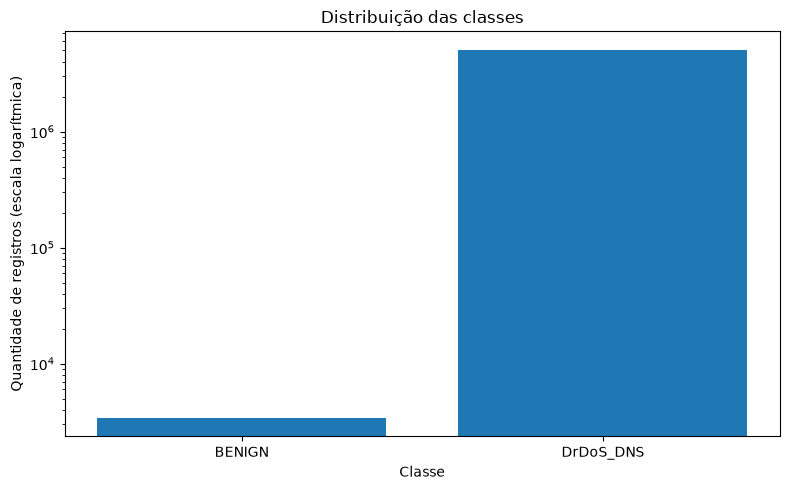

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    classes_pd["label"],
    classes_pd["quantidade"]
)

plt.yscale("log")

plt.title("Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade de registros (escala logarítmica)")

plt.tight_layout()
plt.show()

In [33]:
query = """
SELECT
    flow_duration,
    total_fwd_packets,
    total_backward_packets,
    total_length_of_fwd_packets,
    total_length_of_bwd_packets,
    flow_iat_mean,
    flow_iat_std,
    packet_length_mean,
    packet_length_std
FROM data_drdos_dns
LIMIT 10000
"""

amostra = (
    spark.read
    .format("jdbc")
    .option("url", JDBC_URL)
    .option("query", query)
    .option("user", CH_USER)
    .option("password", CH_PASSWORD)
    .option("driver", "com.clickhouse.jdbc.ClickHouseDriver")
    .load()
)

amostra_pd = amostra.toPandas()

C:\Users\Bruno\downloads\tcc_codigo\railway-ch\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


In [34]:
amostra_pd.shape

(10000, 9)

In [36]:
import pandas as pd

print(amostra_pd.dtypes)

flow_duration                  object
total_fwd_packets              object
total_backward_packets         object
total_length_of_fwd_packets    object
total_length_of_bwd_packets    object
flow_iat_mean                  object
flow_iat_std                   object
packet_length_mean             object
packet_length_std              object
dtype: object


In [37]:
for coluna in amostra_pd.columns:
    amostra_pd[coluna] = pd.to_numeric(
        amostra_pd[coluna],
        errors="coerce"
    )

print(amostra_pd.dtypes)

flow_duration                    int64
total_fwd_packets                int64
total_backward_packets           int64
total_length_of_fwd_packets    float64
total_length_of_bwd_packets    float64
flow_iat_mean                  float64
flow_iat_std                   float64
packet_length_mean             float64
packet_length_std              float64
dtype: object


In [38]:
amostra_pd.head()

,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,flow_iat_mean,flow_iat_std,packet_length_mean,packet_length_std
0,28415,97,0,42680.0,0.0,295.989583,500.959301,440.0,0.0
1,2,2,0,880.0,0.0,2.000000,0.000000,440.0,0.0
2,48549,200,0,88000.0,0.0,243.964824,578.101371,440.0,0.0
3,48337,200,0,88000.0,0.0,242.899497,485.292695,440.0,0.0
4,32026,200,0,88000.0,0.0,160.934673,196.891271,440.0,0.0


In [39]:
amostra_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   flow_duration                10000 non-null  int64  
 1   total_fwd_packets            10000 non-null  int64  
 2   total_backward_packets       10000 non-null  int64  
 3   total_length_of_fwd_packets  10000 non-null  float64
 4   total_length_of_bwd_packets  10000 non-null  float64
 5   flow_iat_mean                10000 non-null  float64
 6   flow_iat_std                 10000 non-null  float64
 7   packet_length_mean           10000 non-null  float64
 8   packet_length_std            10000 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 703.3 KB


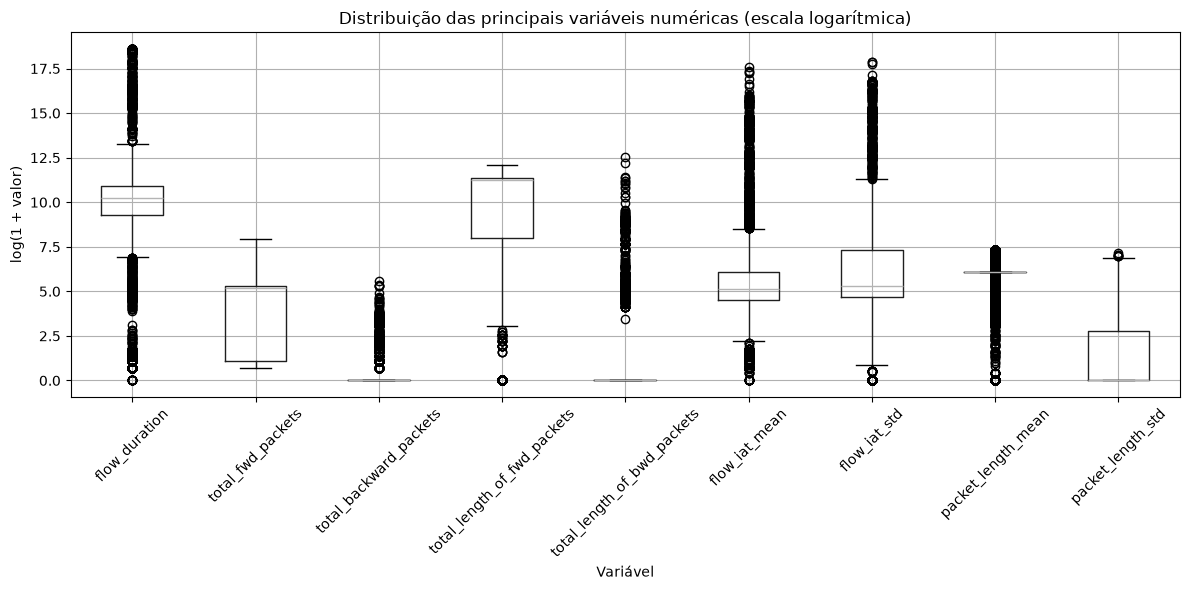

In [41]:
import numpy as np
import matplotlib.pyplot as plt

amostra_log = amostra_pd.copy()

for coluna in amostra_log.columns:
    amostra_log[coluna] = np.log1p(amostra_log[coluna])

plt.figure(figsize=(12, 6))

amostra_log.boxplot()

plt.title("Distribuição das principais variáveis numéricas (escala logarítmica)")
plt.xlabel("Variável")
plt.ylabel("log(1 + valor)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

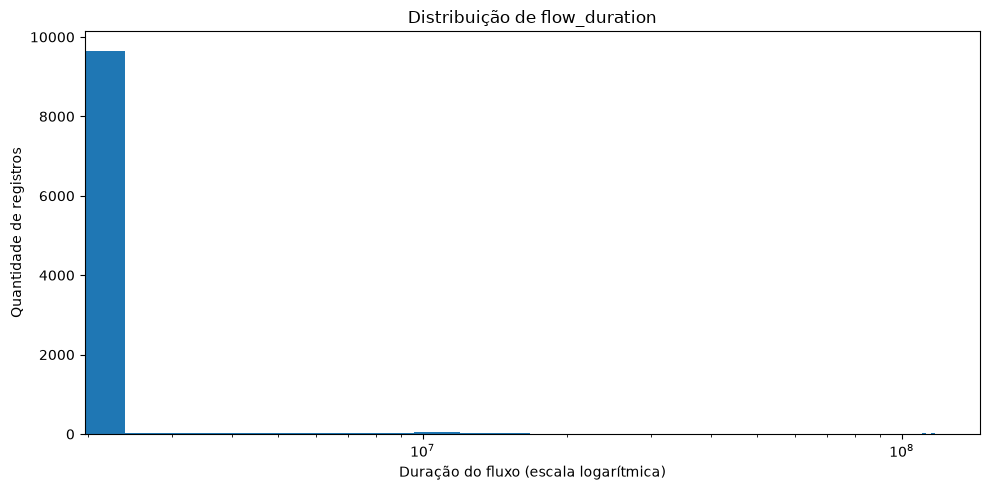

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    amostra_pd["flow_duration"],
    bins=50
)

plt.xscale("log")

plt.title("Distribuição de flow_duration")
plt.xlabel("Duração do fluxo (escala logarítmica)")
plt.ylabel("Quantidade de registros")

plt.tight_layout()
plt.show()

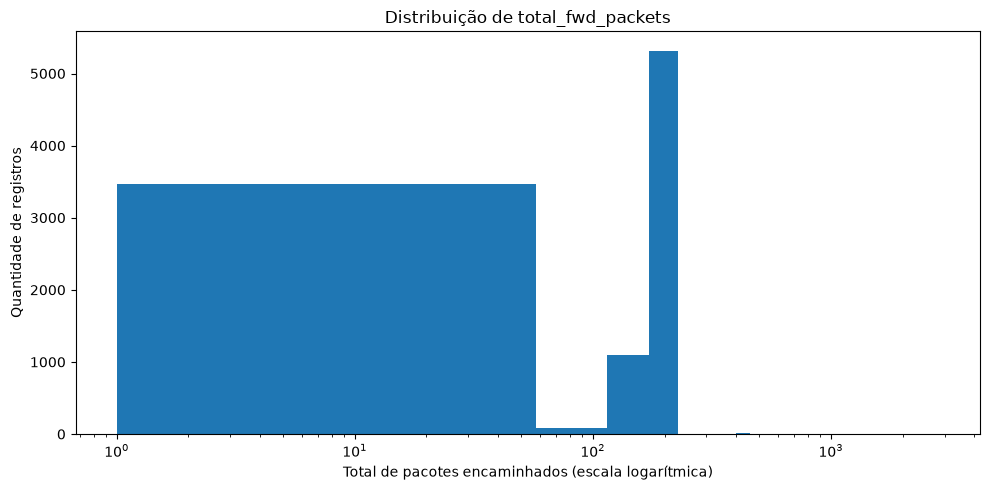

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    amostra_pd["total_fwd_packets"],
    bins=50
)

plt.xscale("log")

plt.title("Distribuição de total_fwd_packets")
plt.xlabel("Total de pacotes encaminhados (escala logarítmica)")
plt.ylabel("Quantidade de registros")

plt.tight_layout()
plt.show()

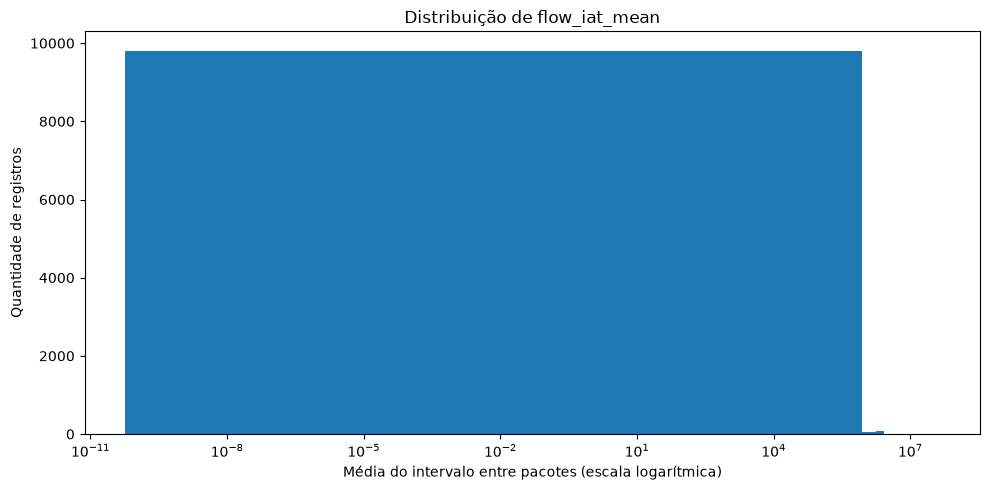

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    amostra_pd["flow_iat_mean"],
    bins=50
)

plt.xscale("log")

plt.title("Distribuição de flow_iat_mean")
plt.xlabel("Média do intervalo entre pacotes (escala logarítmica)")
plt.ylabel("Quantidade de registros")

plt.tight_layout()
plt.show()

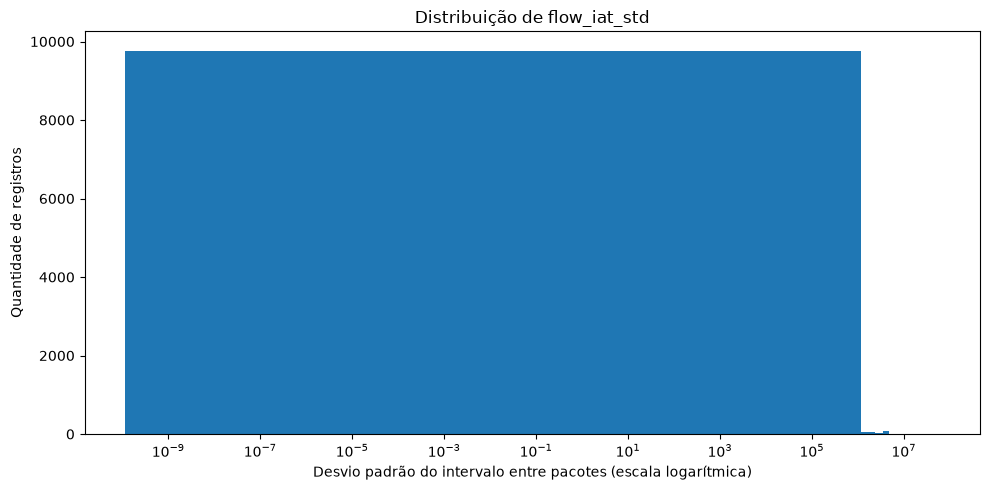

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    amostra_pd["flow_iat_std"],
    bins=50
)

plt.xscale("log")

plt.title("Distribuição de flow_iat_std")
plt.xlabel("Desvio padrão do intervalo entre pacotes (escala logarítmica)")
plt.ylabel("Quantidade de registros")

plt.tight_layout()
plt.show()